# Análise de Dados das UPAs Dinamerica e Alto Branco
## Preparação para Modelagem de Teoria das Filas e Processo de Poisson

**Objetivo:** Analisar os dados de atendimento das duas UPAs para extrair parâmetros essenciais para simulação de filas usando Processo de Poisson.

**Autor:** Análise de Dados - UPAs Campina Grande  
**Data:** Novembro 2025

## 1. Importação de Bibliotecas e Configuração

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings

# Configurações
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Configuração para visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Carregamento dos Dados

In [40]:
# UPA Dinamerica
din_dia = pd.read_csv('/content/atendimento-dia-dinamerica.csv', skiprows=1)
din_hora = pd.read_csv('/content/atendimento-hora-dinamerica.csv', skiprows=2)
din_class = pd.read_csv('/content/classificacao-dia-dinamerica.csv', skiprows=2)

# UPA Alto Branco
alt_dia = pd.read_csv('/content/atendimento-dia-alto-branco.csv', skiprows=1)
alt_hora = pd.read_csv('/content/atendimento-hora-alto-branco.csv', skiprows=2)
alt_class = pd.read_csv('/content/classificacao-dia-alto-branco.csv', skiprows=2)

print("✓ Dados carregados com sucesso!")
print(f"\nDinamerica - Dias: {len(din_dia)}, Horas: {len(din_hora)}, Classificações: {len(din_class)}")
print(f"Alto Branco - Dias: {len(alt_dia)}, Horas: {len(alt_hora)}, Classificações: {len(alt_class)}")

✓ Dados carregados com sucesso!

Dinamerica - Dias: 396, Horas: 24, Classificações: 399
Alto Branco - Dias: 396, Horas: 24, Classificações: 399


## 3. Pré-processamento dos Dados

In [41]:
# Função para processar dados diários
def processar_dados_dia(df, upa_nome):
    df = df.copy()
    df.columns = ['Data', 'Atendimentos']
    df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y', errors='coerce')
    df = df.dropna(subset=['Data'])
    df['Atendimentos'] = pd.to_numeric(df['Atendimentos'], errors='coerce')
    df = df.dropna(subset=['Atendimentos'])

    df['DiaSemana'] = df['Data'].dt.day_name()
    df['DiaSemanaNum'] = df['Data'].dt.dayofweek
    df['Mes'] = df['Data'].dt.month
    df['Ano'] = df['Data'].dt.year
    df['UPA'] = upa_nome

    return df.sort_values('Data')

# Função para processar dados por hora
def processar_dados_hora(df, upa_nome):
    df = df.copy()
    df.columns = ['Periodo', 'Horario', 'Atendimentos', 'Percentual']
    df['Hora'] = df['Periodo'].str.extract(r'(\d+)H')[0].astype(int)
    df['Atendimentos'] = pd.to_numeric(df['Atendimentos'], errors='coerce')
    df['Percentual'] = df['Percentual'].str.replace('%', '').str.replace(',', '.').astype(float) / 100
    df['UPA'] = upa_nome

    return df

# Processar todos os dados
din_dia_clean = processar_dados_dia(din_dia, 'Dinamerica')
alt_dia_clean = processar_dados_dia(alt_dia, 'Alto Branco')

din_hora_clean = processar_dados_hora(din_hora, 'Dinamerica')
alt_hora_clean = processar_dados_hora(alt_hora, 'Alto Branco')

# Processar classificações
din_class_clean = processar_dados_dia(din_class[din_class.columns[:2]], 'Dinamerica')
din_class_clean.columns = ['Data', 'Classificacoes', 'DiaSemana', 'DiaSemanaNum', 'Mes', 'Ano', 'UPA']

alt_class_clean = processar_dados_dia(alt_class[alt_class.columns[:2]], 'Alto Branco')
alt_class_clean.columns = ['Data', 'Classificacoes', 'DiaSemana', 'DiaSemanaNum', 'Mes', 'Ano', 'UPA']

print("✓ Pré-processamento concluído!")
print(f"\nPeríodo Dinamerica: {din_dia_clean['Data'].min()} a {din_dia_clean['Data'].max()}")
print(f"Período Alto Branco: {alt_dia_clean['Data'].min()} a {alt_dia_clean['Data'].max()}")

✓ Pré-processamento concluído!

Período Dinamerica: 2024-10-01 00:00:00 a 2025-10-31 00:00:00
Período Alto Branco: 2024-10-01 00:00:00 a 2025-10-31 00:00:00


## 4. Estatísticas Descritivas Gerais

In [42]:
# Estatísticas gerais
def estatisticas_upa(df_dia, df_hora, nome_upa):
    print(f"\nESTATÍSTICAS - UPA {nome_upa.upper()}")

    print("\nATENDIMENTOS DIÁRIOS:")
    print(df_dia['Atendimentos'].describe())

    print(f"\nTotal de Atendimentos: {df_dia['Atendimentos'].sum():,.0f}")
    print(f"Dias com Dados: {len(df_dia)}")
    print(f"Média Diária: {df_dia['Atendimentos'].mean():.2f} pacientes/dia")
    print(f"Mediana Diária: {df_dia['Atendimentos'].median():.2f} pacientes/dia")
    print(f"Desvio Padrão: {df_dia['Atendimentos'].std():.2f}")
    print(f"Coeficiente de Variação: {(df_dia['Atendimentos'].std()/df_dia['Atendimentos'].mean())*100:.2f}%")

    print(f"\nDISTRIBUIÇÃO POR HORA DO DIA:")
    total_hora = df_hora['Atendimentos'].sum()
    media_hora_real = df_dia['Atendimentos'].mean() / 24

    print(f"Total Acumulado (período completo): {total_hora:,.0f} atendimentos")
    print(f"Média Real por Hora: {media_hora_real:.2f} pacientes/hora")
    print(f"  ↳ Calculado: {df_dia['Atendimentos'].mean():.2f} pac/dia ÷ 24h")

    top_horas = df_hora.nlargest(3, 'Atendimentos')[['Hora', 'Atendimentos', 'Percentual']]
    print("\nTop 3 Horários de Pico (acumulado no período):")
    for idx, row in top_horas.iterrows():
        print(f"  {int(row['Hora']):02d}:00h - {row['Atendimentos']:,.0f} atendimentos ({row['Percentual']*100:.2f}%)")

    return df_dia['Atendimentos'].describe()

stats_din = estatisticas_upa(din_dia_clean, din_hora_clean, 'Dinamerica')
stats_alt = estatisticas_upa(alt_dia_clean, alt_hora_clean, 'Alto Branco')


ESTATÍSTICAS - UPA DINAMERICA

ATENDIMENTOS DIÁRIOS:
count    396.000000
mean     353.727273
std       63.186694
min      207.000000
25%      306.000000
50%      354.500000
75%      396.000000
max      521.000000
Name: Atendimentos, dtype: float64

Total de Atendimentos: 140,076
Dias com Dados: 396
Média Diária: 353.73 pacientes/dia
Mediana Diária: 354.50 pacientes/dia
Desvio Padrão: 63.19
Coeficiente de Variação: 17.86%

DISTRIBUIÇÃO POR HORA DO DIA:
Total Acumulado (período completo): 140,076 atendimentos
Média Real por Hora: 14.74 pacientes/hora
  ↳ Calculado: 353.73 pac/dia ÷ 24h

Top 3 Horários de Pico (acumulado no período):
  09:00h - 9,629 atendimentos (6.87%)
  08:00h - 9,599 atendimentos (6.85%)
  10:00h - 8,730 atendimentos (6.23%)

ESTATÍSTICAS - UPA ALTO BRANCO

ATENDIMENTOS DIÁRIOS:
count    396.000000
mean     249.520202
std       59.395879
min      123.000000
25%      203.750000
50%      254.500000
75%      291.000000
max      404.000000
Name: Atendimentos, dtype: floa

## 5. PARÂMETROS PARA PROCESSO DE POISSON

### 5.1 Taxa de Chegada (λ - Lambda)

In [43]:
def calcular_parametros_poisson(df_dia, df_hora, nome_upa):
    print(f"\nPARÂMETROS PARA PROCESSO DE POISSON - UPA {nome_upa.upper()}")

    # 1. Taxa de chegada média (λ) - por hora
    atendimentos_total = df_hora['Atendimentos'].sum()
    dias_total = len(df_dia)
    horas_operacao = 24

    lambda_hora = df_dia['Atendimentos'].mean() / horas_operacao
    lambda_dia = df_dia['Atendimentos'].mean()

    print(f"\nTAXA DE CHEGADA (λ):")
    print(f"  λ por HORA:   {lambda_hora:.4f} pacientes/hora")
    print(f"  λ por MINUTO: {lambda_hora/60:.4f} pacientes/minuto")
    print(f"  λ por DIA:    {lambda_dia:.4f} pacientes/dia")

    # 2. Variação da taxa por hora do dia
    print(f"\nTAXA DE CHEGADA POR HORA DO DIA:")
    df_hora_sorted = df_hora.sort_values('Hora')
    lambdas_por_hora = []

    for _, row in df_hora_sorted.iterrows():
        lambda_h = row['Atendimentos'] / dias_total
        lambdas_por_hora.append({
            'Hora': int(row['Hora']),
            'Lambda': lambda_h,
            'Percentual': row['Percentual']
        })

    df_lambdas = pd.DataFrame(lambdas_por_hora)

    print("\nTop 5 Horários com Maior λ:")
    for _, row in df_lambdas.nlargest(5, 'Lambda').iterrows():
        print(f"  {int(row['Hora']):02d}:00h - λ = {row['Lambda']:.4f} pacientes/hora ({row['Percentual']*100:.2f}% do total)")

    # 3. Variação da taxa por dia da semana
    print(f"\nTAXA DE CHEGADA POR DIA DA SEMANA:")
    lambda_por_dia_semana = df_dia.groupby('DiaSemana')['Atendimentos'].agg(['mean', 'std', 'count'])

    ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

    for dia_en, dia_pt in zip(ordem_dias, dias_pt):
        if dia_en in lambda_por_dia_semana.index:
            media = lambda_por_dia_semana.loc[dia_en, 'mean']
            std = lambda_por_dia_semana.loc[dia_en, 'std']
            count = lambda_por_dia_semana.loc[dia_en, 'count']
            lambda_hora_dia = media / horas_operacao
            print(f"  {dia_pt:10s}: λ = {lambda_hora_dia:.4f} pacientes/hora (μ={media:.1f}, σ={std:.1f}, n={int(count)})")

    # 4. Teste de aderência à distribuição de Poisson
    print(f"\nTESTE DE ADERÊNCIA À DISTRIBUIÇÃO DE POISSON:")

    # Teste Qui-quadrado
    media_obs = df_dia['Atendimentos'].mean()
    variancia_obs = df_dia['Atendimentos'].var()
    razao_var_media = variancia_obs / media_obs

    print(f"  Média observada:     {media_obs:.2f}")
    print(f"  Variância observada: {variancia_obs:.2f}")
    print(f"  Razão Var/Média:     {razao_var_media:.4f}")

    if abs(razao_var_media - 1) < 0.2:
        print(f"Razão próxima de 1 - BOA aderência à Poisson")
    else:
        print(f"Razão distante de 1 - possível sobredispersão")

    # 5. Intervalo entre chegadas
    tempo_entre_chegadas_min = 60 / lambda_hora
    print(f"\nTEMPO MÉDIO ENTRE CHEGADAS:")
    print(f"  {tempo_entre_chegadas_min:.2f} minutos")
    print(f"  {tempo_entre_chegadas_min*60:.0f} segundos")

    parametros = {
        'lambda_hora': lambda_hora,
        'lambda_dia': lambda_dia,
        'lambda_minuto': lambda_hora/60,
        'lambdas_por_hora': df_lambdas,
        'lambda_por_dia_semana': lambda_por_dia_semana,
        'tempo_entre_chegadas': tempo_entre_chegadas_min,
        'media': media_obs,
        'variancia': variancia_obs,
        'razao_var_media': razao_var_media
    }

    return parametros

params_din = calcular_parametros_poisson(din_dia_clean, din_hora_clean, 'Dinamerica')
params_alt = calcular_parametros_poisson(alt_dia_clean, alt_hora_clean, 'Alto Branco')


PARÂMETROS PARA PROCESSO DE POISSON - UPA DINAMERICA

TAXA DE CHEGADA (λ):
  λ por HORA:   14.7386 pacientes/hora
  λ por MINUTO: 0.2456 pacientes/minuto
  λ por DIA:    353.7273 pacientes/dia

TAXA DE CHEGADA POR HORA DO DIA:

Top 5 Horários com Maior λ:
  09:00h - λ = 24.3157 pacientes/hora (6.87% do total)
  08:00h - λ = 24.2399 pacientes/hora (6.85% do total)
  10:00h - λ = 22.0455 pacientes/hora (6.23% do total)
  07:00h - λ = 21.6641 pacientes/hora (6.12% do total)
  13:00h - λ = 20.9318 pacientes/hora (5.92% do total)

TAXA DE CHEGADA POR DIA DA SEMANA:
  Segunda   : λ = 18.1987 pacientes/hora (μ=436.8, σ=35.1, n=56)
  Terça     : λ = 15.5417 pacientes/hora (μ=373.0, σ=39.9, n=57)
  Quarta    : λ = 15.2010 pacientes/hora (μ=364.8, σ=51.4, n=57)
  Quinta    : λ = 15.5709 pacientes/hora (μ=373.7, σ=39.9, n=57)
  Sexta     : λ = 14.9561 pacientes/hora (μ=358.9, σ=37.2, n=57)
  Sábado    : λ = 12.6228 pacientes/hora (μ=302.9, σ=26.7, n=56)
  Domingo   : λ = 11.0379 pacientes/hora (

### 5.2 Resumo dos Parâmetros para Simulação

In [44]:
print("\nUPA DINAMERICA:")
print(f"  λ (lambda) = {params_din['lambda_hora']:.4f} pacientes/hora")
print(f"  Taxa média diária = {params_din['lambda_dia']:.2f} pacientes/dia")
print(f"  Tempo entre chegadas = {params_din['tempo_entre_chegadas']:.2f} minutos")
print(f"  Adequação Poisson = {'Boa' if abs(params_din['razao_var_media']-1) < 0.2 else 'Moderada'}")

print("\nUPA ALTO BRANCO:")
print(f"  λ (lambda) = {params_alt['lambda_hora']:.4f} pacientes/hora")
print(f"  Taxa média diária = {params_alt['lambda_dia']:.2f} pacientes/dia")
print(f"  Tempo entre chegadas = {params_alt['tempo_entre_chegadas']:.2f} minutos")
print(f"  Adequação Poisson = {'Boa' if abs(params_alt['razao_var_media']-1) < 0.2 else 'Moderada'}")

print("\nDICA PARA SIMULAÇÃO:")
print("  Use processo de Poisson não-homogêneo (taxa λ varia por hora do dia)")
print("  Considere diferentes λ para dias da semana vs. fins de semana")


UPA DINAMERICA:
  λ (lambda) = 14.7386 pacientes/hora
  Taxa média diária = 353.73 pacientes/dia
  Tempo entre chegadas = 4.07 minutos
  Adequação Poisson = Moderada

UPA ALTO BRANCO:
  λ (lambda) = 10.3967 pacientes/hora
  Taxa média diária = 249.52 pacientes/dia
  Tempo entre chegadas = 5.77 minutos
  Adequação Poisson = Moderada

DICA PARA SIMULAÇÃO:
  Use processo de Poisson não-homogêneo (taxa λ varia por hora do dia)
  Considere diferentes λ para dias da semana vs. fins de semana


## 6. Visualizações - Distribuição de Chegadas

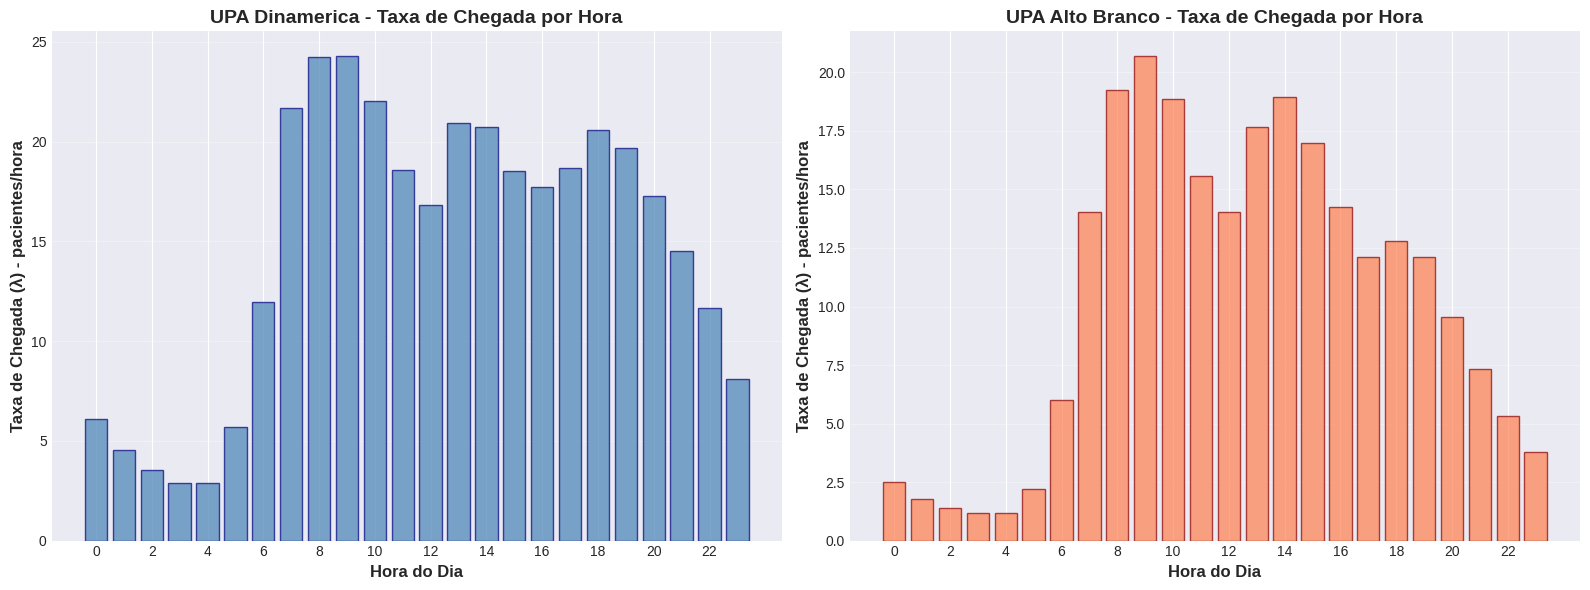

In [45]:
# 6.1 Distribuição por Hora do Dia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Dinamerica
ax1.bar(params_din['lambdas_por_hora']['Hora'],
        params_din['lambdas_por_hora']['Lambda'],
        color='steelblue', alpha=0.7, edgecolor='navy')
ax1.set_xlabel('Hora do Dia', fontsize=12, fontweight='bold')
ax1.set_ylabel('Taxa de Chegada (λ) - pacientes/hora', fontsize=12, fontweight='bold')
ax1.set_title('UPA Dinamerica - Taxa de Chegada por Hora', fontsize=14, fontweight='bold')
ax1.set_xticks(range(0, 24, 2))
ax1.grid(axis='y', alpha=0.3)

# Alto Branco
ax2.bar(params_alt['lambdas_por_hora']['Hora'],
        params_alt['lambdas_por_hora']['Lambda'],
        color='coral', alpha=0.7, edgecolor='darkred')
ax2.set_xlabel('Hora do Dia', fontsize=12, fontweight='bold')
ax2.set_ylabel('Taxa de Chegada (λ) - pacientes/hora', fontsize=12, fontweight='bold')
ax2.set_title('UPA Alto Branco - Taxa de Chegada por Hora', fontsize=14, fontweight='bold')
ax2.set_xticks(range(0, 24, 2))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

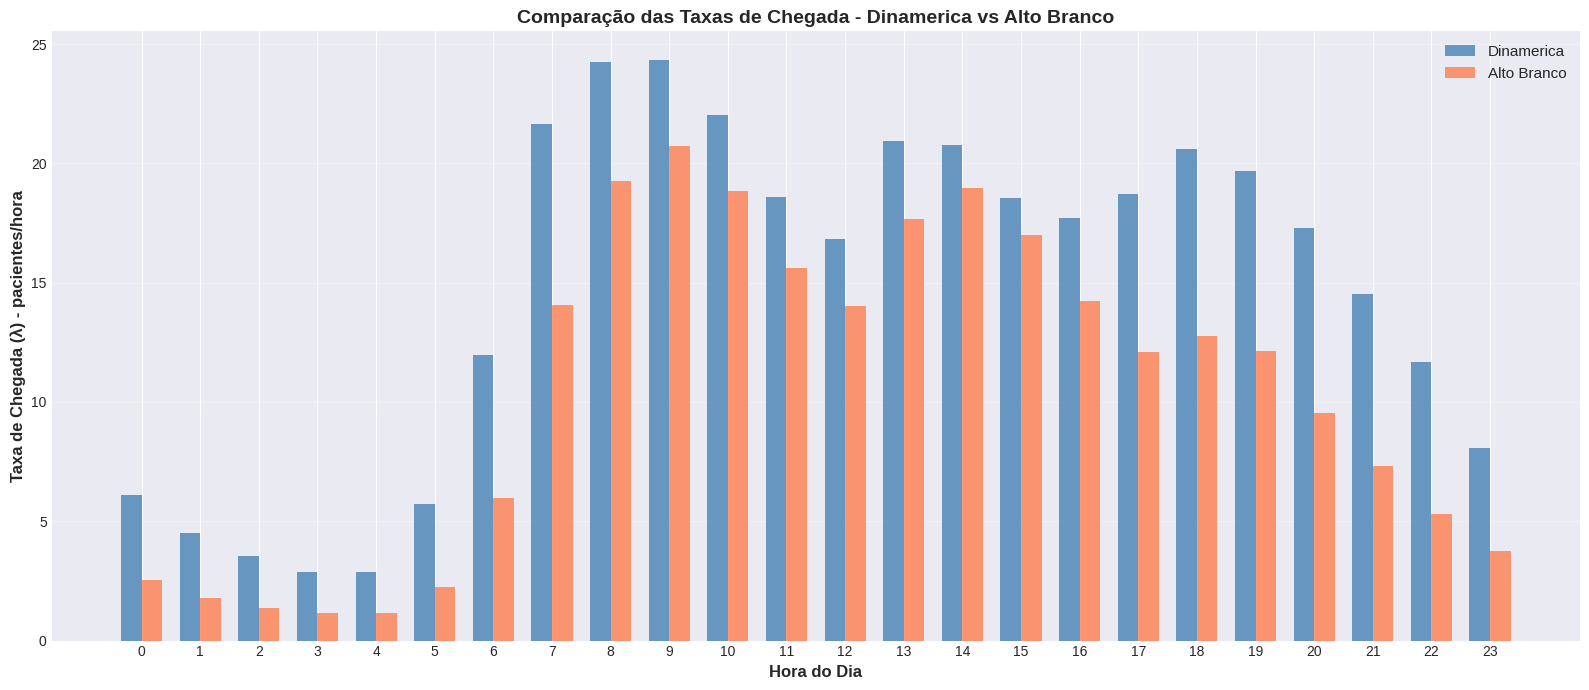

In [46]:
# 6.2 Comparação Direta das Duas UPAs
fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(24)
width = 0.35

ax.bar(x - width/2, params_din['lambdas_por_hora']['Lambda'],
       width, label='Dinamerica', color='steelblue', alpha=0.8)
ax.bar(x + width/2, params_alt['lambdas_por_hora']['Lambda'],
       width, label='Alto Branco', color='coral', alpha=0.8)

ax.set_xlabel('Hora do Dia', fontsize=12, fontweight='bold')
ax.set_ylabel('Taxa de Chegada (λ) - pacientes/hora', fontsize=12, fontweight='bold')
ax.set_title('Comparação das Taxas de Chegada - Dinamerica vs Alto Branco',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

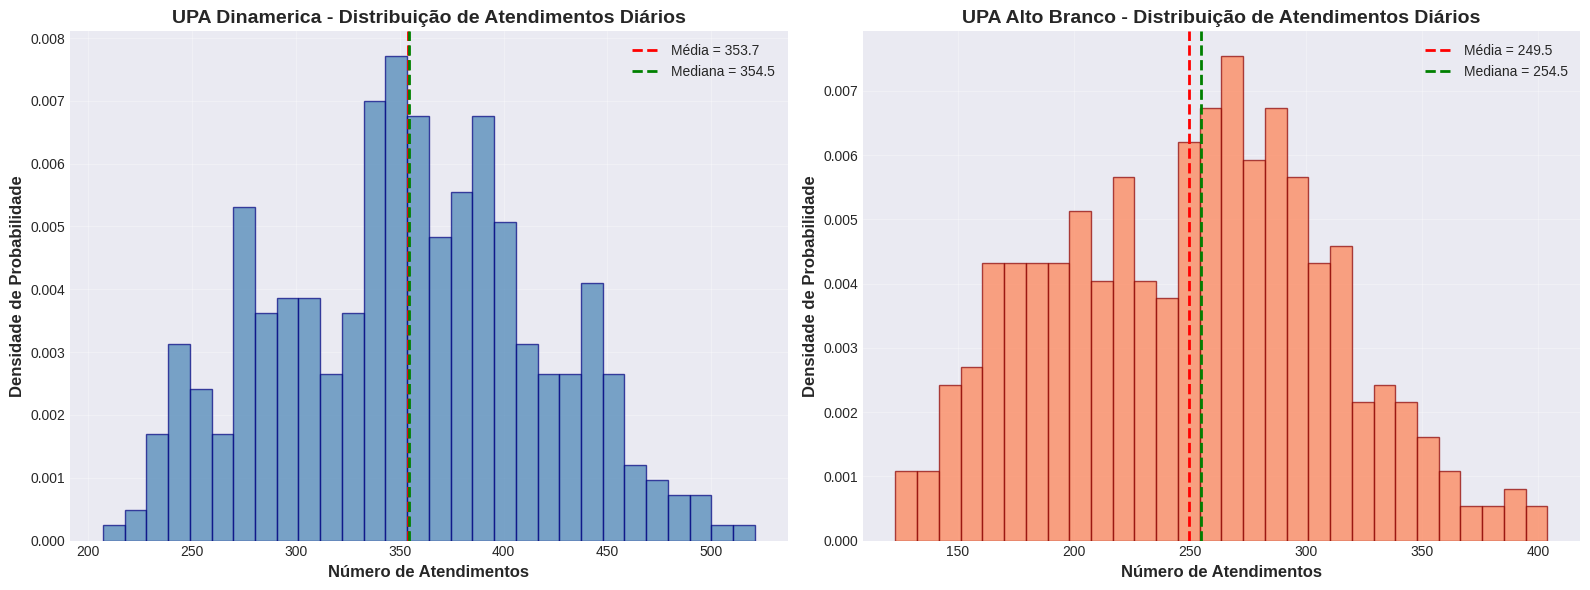

In [47]:
# 6.3 Distribuição de Atendimentos Diários (Histograma)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Dinamerica
ax1.hist(din_dia_clean['Atendimentos'], bins=30, color='steelblue',
         alpha=0.7, edgecolor='navy', density=True)
ax1.axvline(din_dia_clean['Atendimentos'].mean(), color='red',
            linestyle='--', linewidth=2, label=f"Média = {din_dia_clean['Atendimentos'].mean():.1f}")
ax1.axvline(din_dia_clean['Atendimentos'].median(), color='green',
            linestyle='--', linewidth=2, label=f"Mediana = {din_dia_clean['Atendimentos'].median():.1f}")
ax1.set_xlabel('Número de Atendimentos', fontsize=12, fontweight='bold')
ax1.set_ylabel('Densidade de Probabilidade', fontsize=12, fontweight='bold')
ax1.set_title('UPA Dinamerica - Distribuição de Atendimentos Diários', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Alto Branco
ax2.hist(alt_dia_clean['Atendimentos'], bins=30, color='coral',
         alpha=0.7, edgecolor='darkred', density=True)
ax2.axvline(alt_dia_clean['Atendimentos'].mean(), color='red',
            linestyle='--', linewidth=2, label=f"Média = {alt_dia_clean['Atendimentos'].mean():.1f}")
ax2.axvline(alt_dia_clean['Atendimentos'].median(), color='green',
            linestyle='--', linewidth=2, label=f"Mediana = {alt_dia_clean['Atendimentos'].median():.1f}")
ax2.set_xlabel('Número de Atendimentos', fontsize=12, fontweight='bold')
ax2.set_ylabel('Densidade de Probabilidade', fontsize=12, fontweight='bold')
ax2.set_title('UPA Alto Branco - Distribuição de Atendimentos Diários', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Análise Temporal - Padrões Semanais e Sazonais

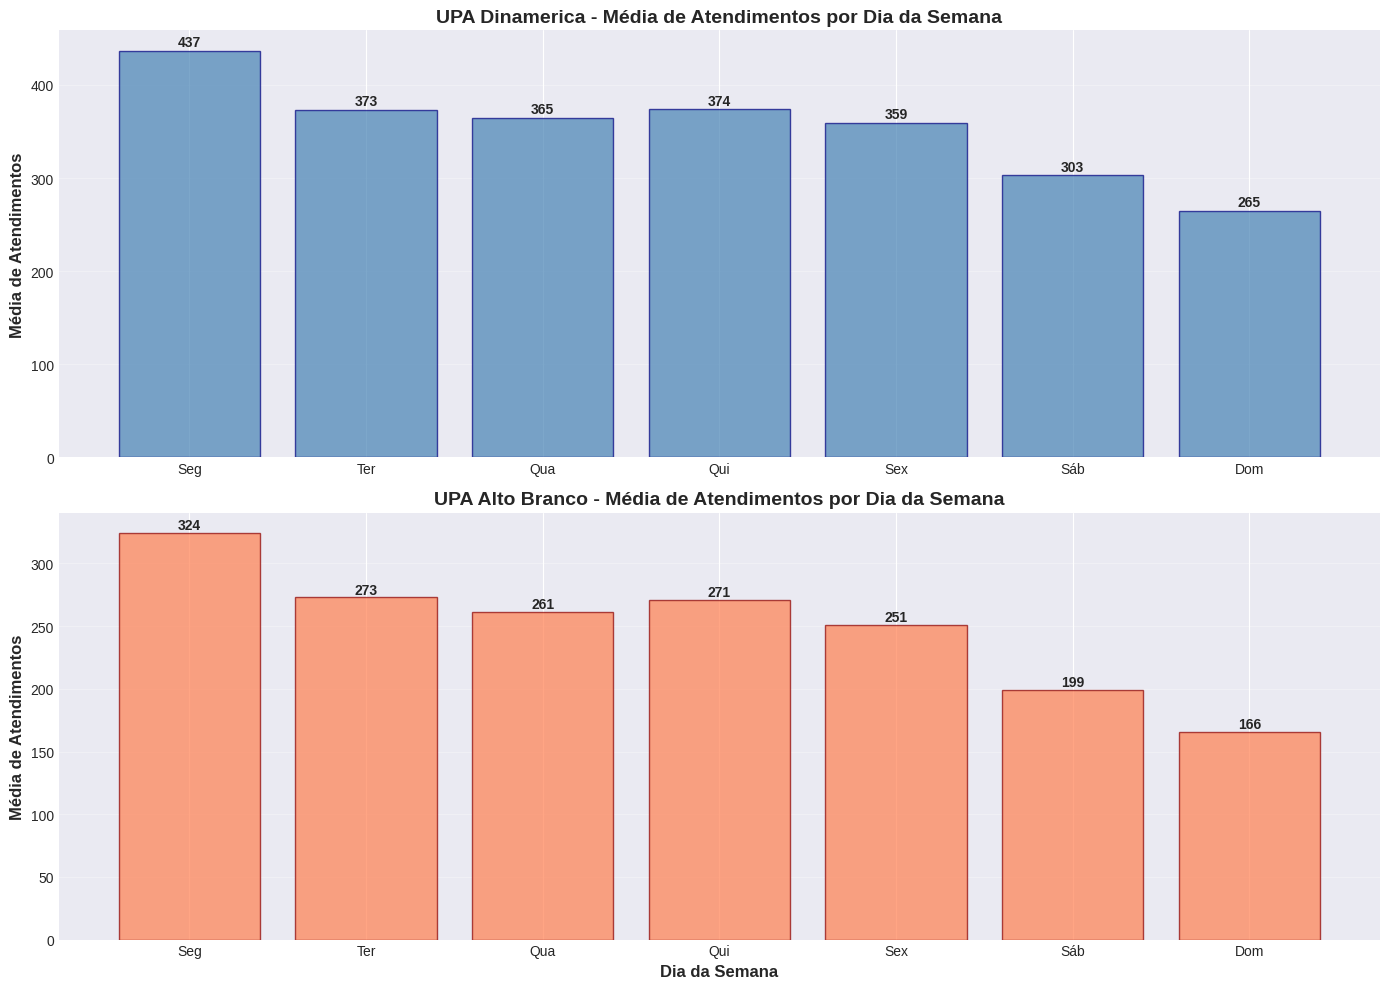

In [48]:
# 7.1 Atendimentos por Dia da Semana
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_pt = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

# Dinamerica
dia_semana_din = din_dia_clean.groupby('DiaSemana')['Atendimentos'].mean().reindex(ordem_dias)
ax1.bar(dias_pt, dia_semana_din.values, color='steelblue', alpha=0.7, edgecolor='navy')
ax1.set_ylabel('Média de Atendimentos', fontsize=12, fontweight='bold')
ax1.set_title('UPA Dinamerica - Média de Atendimentos por Dia da Semana',
              fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(dia_semana_din.values):
    ax1.text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

# Alto Branco
dia_semana_alt = alt_dia_clean.groupby('DiaSemana')['Atendimentos'].mean().reindex(ordem_dias)
ax2.bar(dias_pt, dia_semana_alt.values, color='coral', alpha=0.7, edgecolor='darkred')
ax2.set_ylabel('Média de Atendimentos', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dia da Semana', fontsize=12, fontweight='bold')
ax2.set_title('UPA Alto Branco - Média de Atendimentos por Dia da Semana',
              fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for i, v in enumerate(dia_semana_alt.values):
    ax2.text(i, v + 3, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

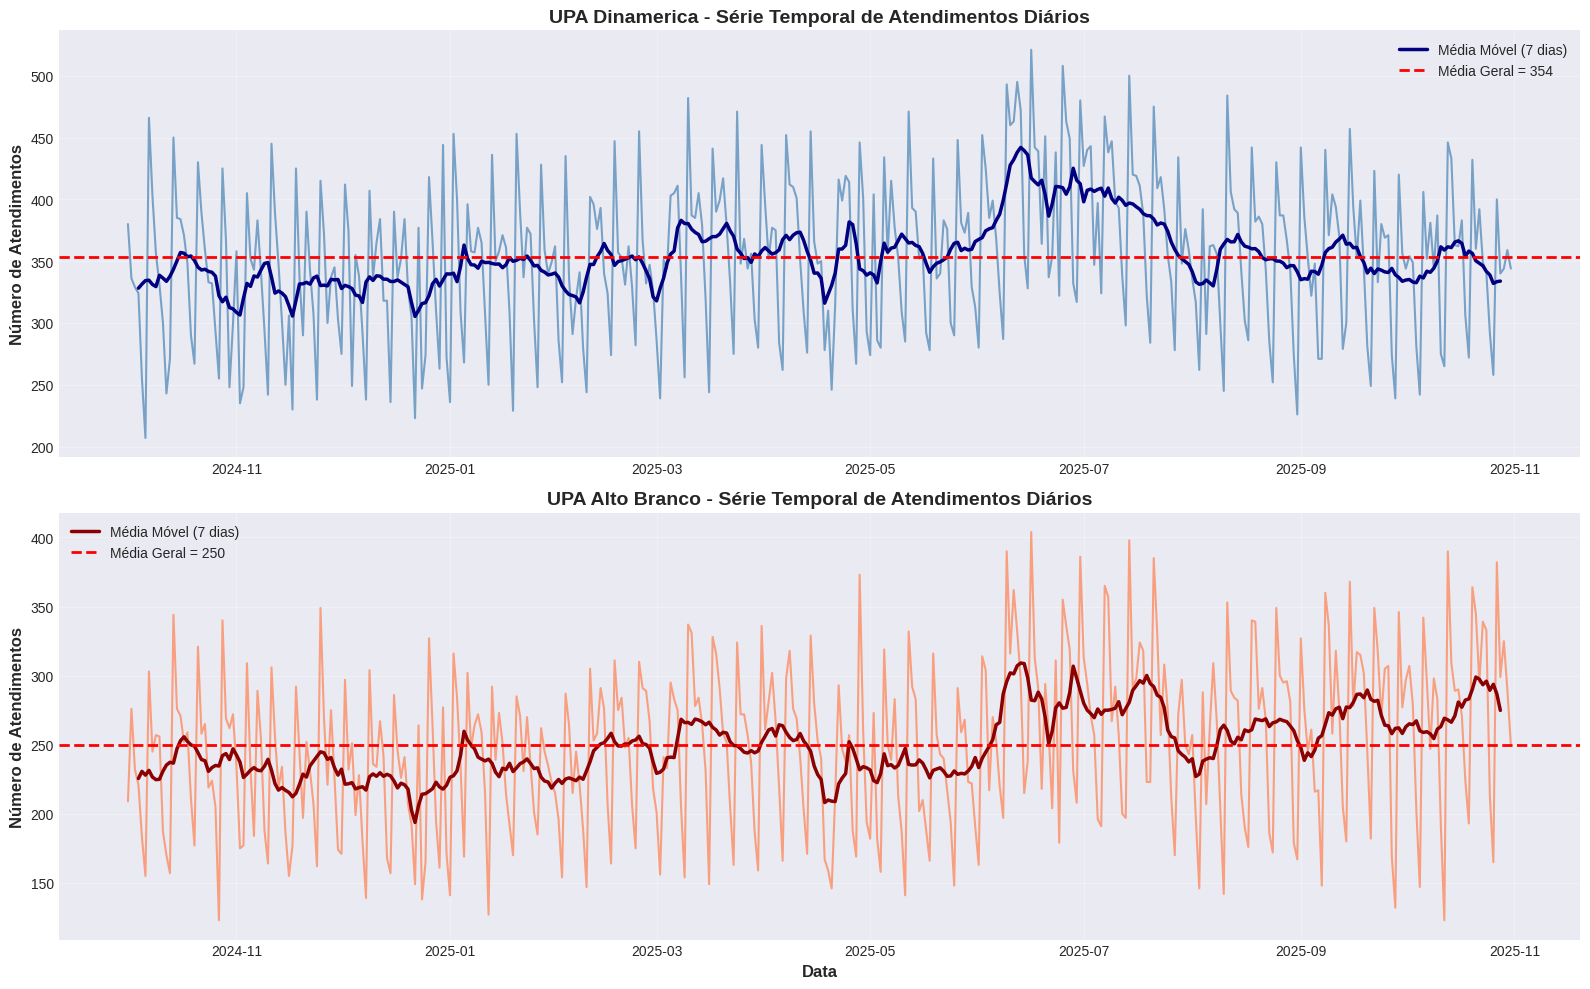

In [49]:
# 7.2 Série Temporal de Atendimentos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Dinamerica
ax1.plot(din_dia_clean['Data'], din_dia_clean['Atendimentos'],
         color='steelblue', linewidth=1.5, alpha=0.7)
ax1.plot(din_dia_clean['Data'],
         din_dia_clean['Atendimentos'].rolling(window=7, center=True).mean(),
         color='navy', linewidth=2.5, label='Média Móvel (7 dias)')
ax1.axhline(din_dia_clean['Atendimentos'].mean(), color='red',
            linestyle='--', linewidth=2, label=f"Média Geral = {din_dia_clean['Atendimentos'].mean():.0f}")
ax1.set_ylabel('Número de Atendimentos', fontsize=12, fontweight='bold')
ax1.set_title('UPA Dinamerica - Série Temporal de Atendimentos Diários',
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Alto Branco
ax2.plot(alt_dia_clean['Data'], alt_dia_clean['Atendimentos'],
         color='coral', linewidth=1.5, alpha=0.7)
ax2.plot(alt_dia_clean['Data'],
         alt_dia_clean['Atendimentos'].rolling(window=7, center=True).mean(),
         color='darkred', linewidth=2.5, label='Média Móvel (7 dias)')
ax2.axhline(alt_dia_clean['Atendimentos'].mean(), color='red',
            linestyle='--', linewidth=2, label=f"Média Geral = {alt_dia_clean['Atendimentos'].mean():.0f}")
ax2.set_xlabel('Data', fontsize=12, fontweight='bold')
ax2.set_ylabel('Número de Atendimentos', fontsize=12, fontweight='bold')
ax2.set_title('UPA Alto Branco - Série Temporal de Atendimentos Diários',
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Teste de Aderência à Distribuição de Poisson

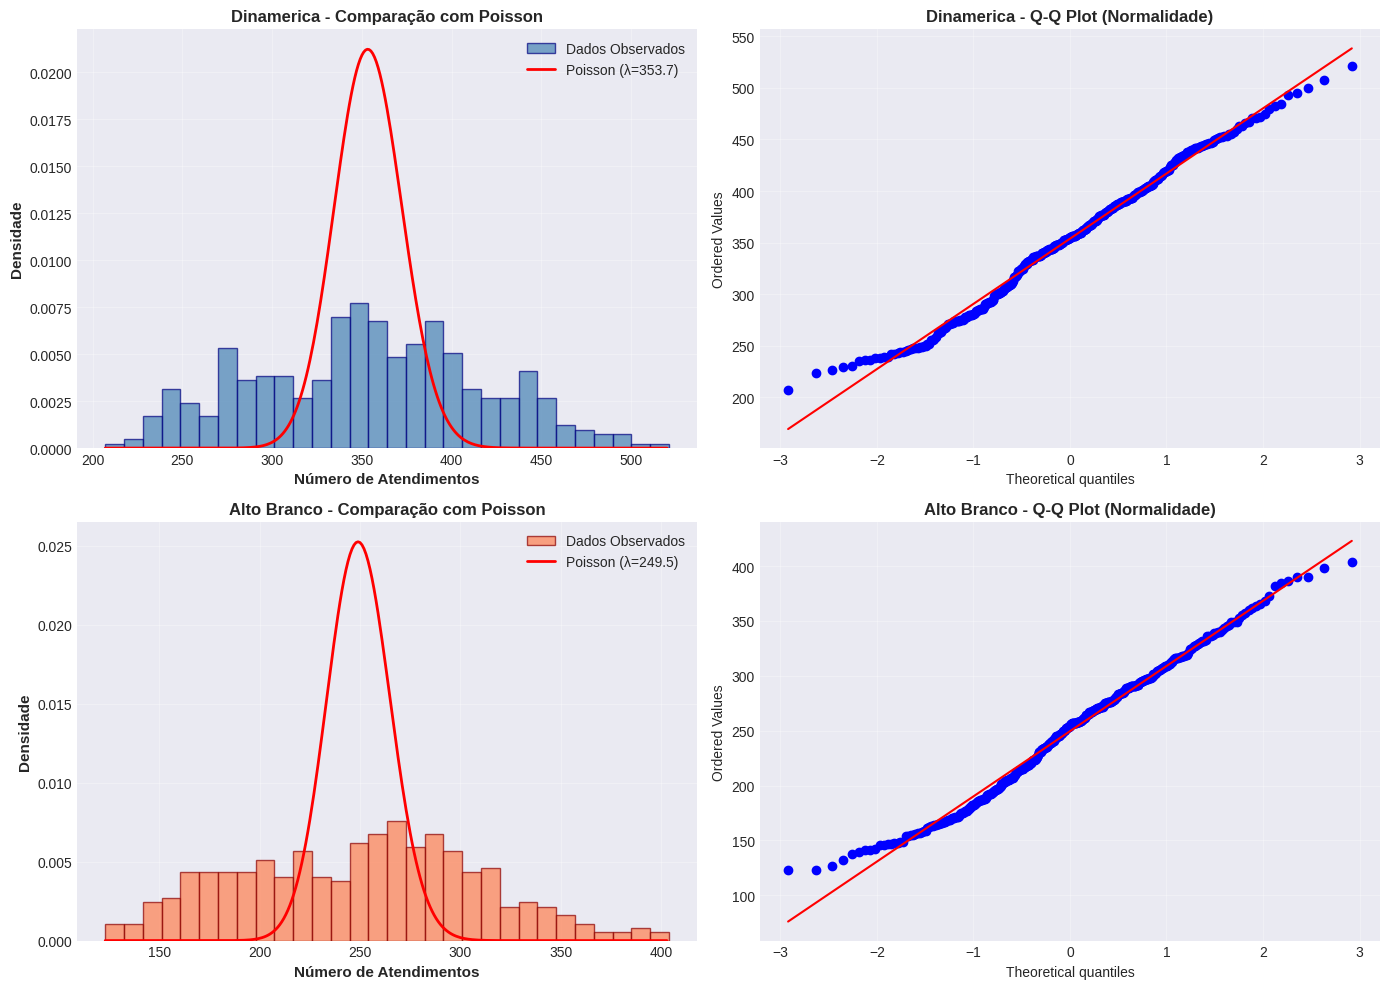

In [50]:
# 9.1 Q-Q Plot para testar normalidade/Poisson
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dinamerica - Histograma com Poisson teórica
ax = axes[0, 0]
counts, bins, _ = ax.hist(din_dia_clean['Atendimentos'], bins=30,
                          density=True, alpha=0.7, color='steelblue',
                          edgecolor='navy', label='Dados Observados')

# Poisson teórica
lambda_din = din_dia_clean['Atendimentos'].mean()
x_range = np.arange(din_dia_clean['Atendimentos'].min(),
                    din_dia_clean['Atendimentos'].max())
poisson_pmf = stats.poisson.pmf(x_range, lambda_din)
ax.plot(x_range, poisson_pmf, 'r-', linewidth=2, label=f'Poisson (λ={lambda_din:.1f})')

ax.set_xlabel('Número de Atendimentos', fontsize=11, fontweight='bold')
ax.set_ylabel('Densidade', fontsize=11, fontweight='bold')
ax.set_title('Dinamerica - Comparação com Poisson', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Dinamerica - Q-Q Plot
ax = axes[0, 1]
stats.probplot(din_dia_clean['Atendimentos'], dist="norm", plot=ax)
ax.set_title('Dinamerica - Q-Q Plot (Normalidade)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# Alto Branco - Histograma com Poisson teórica
ax = axes[1, 0]
counts, bins, _ = ax.hist(alt_dia_clean['Atendimentos'], bins=30,
                          density=True, alpha=0.7, color='coral',
                          edgecolor='darkred', label='Dados Observados')

# Poisson teórica
lambda_alt = alt_dia_clean['Atendimentos'].mean()
x_range = np.arange(alt_dia_clean['Atendimentos'].min(),
                    alt_dia_clean['Atendimentos'].max())
poisson_pmf = stats.poisson.pmf(x_range, lambda_alt)
ax.plot(x_range, poisson_pmf, 'r-', linewidth=2, label=f'Poisson (λ={lambda_alt:.1f})')

ax.set_xlabel('Número de Atendimentos', fontsize=11, fontweight='bold')
ax.set_ylabel('Densidade', fontsize=11, fontweight='bold')
ax.set_title('Alto Branco - Comparação com Poisson', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Alto Branco - Q-Q Plot
ax = axes[1, 1]
stats.probplot(alt_dia_clean['Atendimentos'], dist="norm", plot=ax)
ax.set_title('Alto Branco - Q-Q Plot (Normalidade)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Exportar Parâmetros para Simulação

In [51]:
# Criar dicionário com todos os parâmetros necessários para simulação
parametros_simulacao = {
    'Dinamerica': {
        'lambda_hora_media': params_din['lambda_hora'],
        'lambda_dia': params_din['lambda_dia'],
        'lambda_por_hora': params_din['lambdas_por_hora'].to_dict('records'),
        'tempo_entre_chegadas_minutos': params_din['tempo_entre_chegadas'],
        'dias_semana': {
            dia_pt: {
                'media': params_din['lambda_por_dia_semana'].loc[dia_en, 'mean'],
                'std': params_din['lambda_por_dia_semana'].loc[dia_en, 'std'],
                'lambda_hora': params_din['lambda_por_dia_semana'].loc[dia_en, 'mean'] / 24
            }
            for dia_en, dia_pt in zip(ordem_dias, dias_pt)
            if dia_en in params_din['lambda_por_dia_semana'].index
        }
    },
    'Alto_Branco': {
        'lambda_hora_media': params_alt['lambda_hora'],
        'lambda_dia': params_alt['lambda_dia'],
        'lambda_por_hora': params_alt['lambdas_por_hora'].to_dict('records'),
        'tempo_entre_chegadas_minutos': params_alt['tempo_entre_chegadas'],
        'dias_semana': {
            dia_pt: {
                'media': params_alt['lambda_por_dia_semana'].loc[dia_en, 'mean'],
                'std': params_alt['lambda_por_dia_semana'].loc[dia_en, 'std'],
                'lambda_hora': params_alt['lambda_por_dia_semana'].loc[dia_en, 'mean'] / 24
            }
            for dia_en, dia_pt in zip(ordem_dias, dias_pt)
            if dia_en in params_alt['lambda_por_dia_semana'].index
        }
    }
}

import json
with open('parametros_simulacao_upas.json', 'w', encoding='utf-8') as f:
    json.dump(parametros_simulacao, f, indent=2, ensure_ascii=False)